Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2499
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1550
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1326
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1225
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1166
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


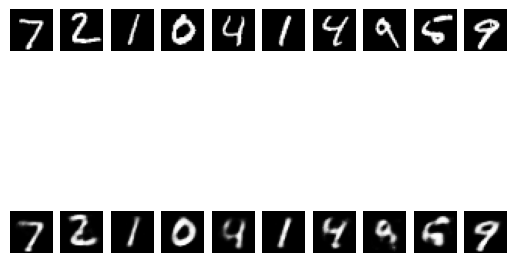

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

(x_train,_),(x_test,_)=keras.datasets.mnist.load_data()

x_train=x_train/255.0
x_test=x_test/255.0

x_train=x_train.reshape(-1,784)
x_test=x_test.reshape(-1,784)

encoder=keras.Sequential([
    keras.layers.Dense(64,activation='relu'),
    keras.layers.Dense(32,activation='relu')
])

decoder=keras.Sequential([
    keras.layers.Dense(64,activation='relu'),
    keras.layers.Dense(784,activation='sigmoid')
])

inp=keras.Input(shape=(784,))
encoded=encoder(inp)
decoded=decoder(encoded)

vae=keras.Model(inp,decoded)
vae.compile(optimizer='adam',loss='binary_crossentropy')

vae.fit(x_train,x_train,epochs=5,batch_size=256)

decoded_imgs=vae.predict(x_test[:10])

for i in range(10):
    plt.subplot(2,10,i+1)
    plt.imshow(x_test[i].reshape(28,28),cmap='gray')
    plt.axis('off')

    plt.subplot(2,10,i+11)
    plt.imshow(decoded_imgs[i].reshape(28,28),cmap='gray')
    plt.axis('off')

plt.show()